# 01 Exploratory data analysis and frame rotation

Goals of this notebook:

1. Determine the range heading and rotate every track into a downrange / lateral / height frame.
2. Work out how the checkpoint lines are defined.
3. Check whether `landing_z` is simply `launch_z`.
4. Cluster `launch_time` into practice sessions for grouped cross-validation.
5. Produce the core exploratory figures.

Reusable logic lives in `src/inrange/`; this notebook only calls it and plots.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from inrange.io import load_train, load_test, CHECKPOINT_NAMES, INPUT_COLS
from inrange.frame import (
    HEADING_RAD, HEADING_DEG, TEE_LINE_PROJECTION, DOWNRANGE_UNIT, LATERAL_UNIT,
    estimate_heading, add_shot_frame, from_shot_frame,
)
from inrange.features import assign_sessions, assign_tees, ELEVATED_TEE_MIN_Z

FIG_DIR = REPO / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Validated categorical slots 1-3 (light mode) and neutral inks.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK_2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "figure.dpi": 110,
    "legend.frameon": False,
})

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## Load data

Train and test inputs are analysed together wherever targets are not needed, because geometry and sessions are properties of the range, not of the split.

In [2]:
train = load_train()
test = load_test()
both = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
both["session"] = assign_sessions(both["launch_time"])
both["tee"] = assign_tees(both)
both = add_shot_frame(both)
train_f = both[both["split"] == "train"].copy()
print(f"train rows: {len(train)}, test rows: {len(test)}")
print(f"missing values: train {train.isna().sum().sum()}, test {test.isna().sum().sum()}")

train rows: 491, test rows: 559
missing values: train 0, test 0


## 1. Range heading

The description says the range points along a fixed diagonal heading, but not which. A naive estimate is the mean bearing from tee to each checkpoint. That is biased by any systematic curve in the shots.

A sharper approach uses the checkpoint definition itself: each checkpoint is the crossing of a *downrange line*. If those lines are perpendicular to the heading, then projecting every crossing onto the true heading gives the same value for all tracks. We find the angle that minimises the spread of those projections.

In [3]:
naive = {}
for cp in CHECKPOINT_NAMES:
    bearing = np.degrees(np.arctan2(both[f"{cp}_y"] - both["launch_y"], both[f"{cp}_x"] - both["launch_x"]))
    naive[cp] = bearing.mean()
print("naive mean bearing per checkpoint (deg):", {k: round(v, 2) for k, v in naive.items()})

theta = estimate_heading(both)
print(f"fitted heading: {np.degrees(theta):.6f} deg (stored constant {HEADING_DEG:.6f} deg)")

projections = pd.DataFrame({
    cp: both[f"{cp}_x"] * DOWNRANGE_UNIT[0] + both[f"{cp}_y"] * DOWNRANGE_UNIT[1] for cp in CHECKPOINT_NAMES
})
summary = projections.agg(["mean", "std", "min", "max"]).T
summary["relative to tee line (m)"] = summary["mean"] - TEE_LINE_PROJECTION
print(summary.round(9))

naive mean bearing per checkpoint (deg): {'cp1': np.float64(25.72), 'cp2': np.float64(25.75), 'cp3': np.float64(25.79), 'cp4': np.float64(25.83)}
fitted heading: 28.366574 deg (stored constant 28.366574 deg)
          mean  std        min        max  relative to tee line (m)
cp1  10.862079  0.0  10.862079  10.862079                 15.000000
cp2  25.862078  0.0  25.862078  25.862078                 29.999999
cp3  40.862076  0.0  40.862076  40.862076                 44.999997
cp4  55.862074  0.0  55.862074  55.862074                 59.999995


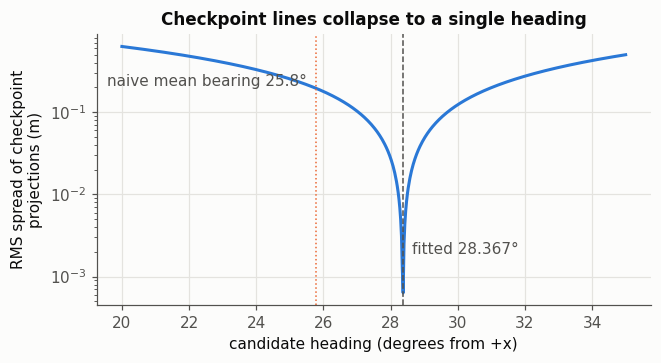

In [4]:
angles = np.linspace(np.radians(20), np.radians(35), 601)
def spread_rms(t):
    u = np.array([np.cos(t), np.sin(t)])
    res = [both[f"{cp}_x"] * u[0] + both[f"{cp}_y"] * u[1] for cp in CHECKPOINT_NAMES]
    return np.sqrt(np.mean([((r - r.mean()) ** 2).mean() for r in res]))
rms = np.array([spread_rms(t) for t in angles])

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(np.degrees(angles), rms, color=BLUE, lw=2)
ax.axvline(HEADING_DEG, color=INK_2, lw=1, ls="--")
ax.axvline(np.mean(list(naive.values())), color=ORANGE, lw=1, ls=":")
ax.set_yscale("log")
ax.set_xlabel("candidate heading (degrees from +x)")
ax.set_ylabel("RMS spread of checkpoint\nprojections (m)")
ax.set_title("Checkpoint lines collapse to a single heading")
ax.annotate(f"fitted {HEADING_DEG:.3f}°", (HEADING_DEG, rms.min() * 3), xytext=(6, 0), textcoords="offset points", color=INK_2)
ax.annotate(f"naive mean bearing {np.mean(list(naive.values())):.1f}°", (np.mean(list(naive.values())), rms.max() / 3),
            xytext=(-6, 0), textcoords="offset points", ha="right", color=INK_2)
save(fig, "fig02_heading_fit")
plt.show()

**Finding.** At the fitted heading of 28.367° from +x the spread of every checkpoint's projection is zero to printed precision (the curve bottoms out near 1e-3 m only because of the plotting grid). The checkpoint lines are fixed lines across the range, spaced 15 m apart (to within 5 µm) and measured from one **common tee line**, not from each individual tee. The naive mean bearing (25.7° to 25.8°) is off by about 2.6° because the average shot starts and curves left of the target line.

In [5]:
tees = both.groupby("tee")[["launch_x", "launch_y", "launch_z", "tee_d"]].first()
tees["shots"] = both.groupby("tee").size()
print(tees.round(4))

     launch_x  launch_y  launch_z   tee_d  shots
tee                                             
T1    -24.900    37.467     0.067  0.0287    442
T2    -23.344    34.627     0.061  0.0486    259
T3    -22.744    30.764     4.125 -1.2588    293
T4    -21.456    31.779     0.054  0.3568     56


There are only four tee positions. Three are at ground level and within 0.36 m of the common tee line. Tee **T3** is elevated (z = 4.125 m, an upper-tier bay) and sits 1.26 m behind the line, so its checkpoints are really at about 16.3, 31.3, 46.3 and 61.3 m from the tee. Any feature that assumes "cp1 is 15 m from launch" must use `tee_d`.

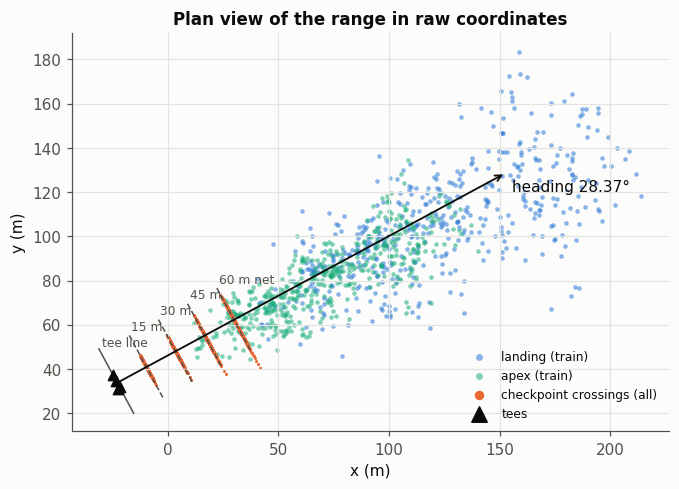

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.2))
t = train_f
ax.scatter(t["landing_x"], t["landing_y"], s=9, color=BLUE, alpha=0.55, lw=0, label="landing (train)")
ax.scatter(t["apex_x"], t["apex_y"], s=9, color=AQUA, alpha=0.55, lw=0, label="apex (train)")
for cp in CHECKPOINT_NAMES:
    ax.scatter(both[f"{cp}_x"], both[f"{cp}_y"], s=4, color=ORANGE, lw=0)
ax.scatter([], [], s=12, color=ORANGE, label="checkpoint crossings (all)")

# Checkpoint lines and the tee line, drawn perpendicular to the heading.
origin_d = TEE_LINE_PROJECTION
for dist, label in [(0, "tee line"), (15, "15 m"), (30, "30 m"), (45, "45 m"), (60, "60 m net")]:
    base = (origin_d + dist) * DOWNRANGE_UNIT
    ends = np.array([base + s * LATERAL_UNIT for s in (25, 58)])
    ax.plot(ends[:, 0], ends[:, 1], color=INK_2, lw=1, ls="--" if dist else "-")
    ax.annotate(label, ends[1], xytext=(2, 2), textcoords="offset points", color=INK_2, fontsize=8)
ax.scatter(tees["launch_x"], tees["launch_y"], marker="^", s=45, color=INK, zorder=5, label="tees")
arrow_start = tees[["launch_x", "launch_y"]].mean().to_numpy()
ax.annotate("", arrow_start + 200 * DOWNRANGE_UNIT, arrow_start,
            arrowprops=dict(arrowstyle="->", color=INK, lw=1.2))
ax.annotate(f"heading {HEADING_DEG:.2f}°", arrow_start + 200 * DOWNRANGE_UNIT, xytext=(4, -12), textcoords="offset points")
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Plan view of the range in raw coordinates")
ax.legend(loc="lower right", fontsize=8, markerscale=1.5)
save(fig, "fig01_plan_view")
plt.show()

## 2. Shot frame

`inrange.frame.add_shot_frame` rotates every point into a right-handed frame centred on the shot's own tee: `d` downrange, `l` lateral (positive to the left), `h` height above the tee. Launch is at the origin and level landing is at `h = 0` by definition. Rotations are checked by a round trip.

In [7]:
x, y, z = from_shot_frame(both["landing_d"], both["landing_l"], both["landing_h"],
                          both["launch_x"], both["launch_y"], both["launch_z"])
print("round-trip max error (m):", float(np.nanmax(np.abs(np.r_[x - both["landing_x"], y - both["landing_y"], z - both["landing_z"]]))))
for cp in CHECKPOINT_NAMES:
    from_line = both[f"{cp}_d"] + both["tee_d"]
    print(f"{cp}: distance from tee line min {from_line.min():.6f} max {from_line.max():.6f} m; "
          f"lateral mean {both[f'{cp}_l'].mean():+.2f} sd {both[f'{cp}_l'].std():.2f} m")
cols = ["launch_vd", "launch_vl", "launch_vh", "apex_d", "apex_l", "apex_h", "landing_d", "landing_l", "landing_h"]
print(train_f[cols].describe().round(2).T)

round-trip max error (m): 5.684341886080802e-14
cp1: distance from tee line min 15.000000 max 15.000000 m; lateral mean -0.72 sd 1.22 m
cp2: distance from tee line min 29.999999 max 29.999999 m; lateral mean -1.40 sd 2.40 m
cp3: distance from tee line min 44.999997 max 44.999997 m; lateral mean -2.06 sd 3.60 m
cp4: distance from tee line min 59.999995 max 59.999995 m; lateral mean -2.69 sd 4.88 m
           count    mean    std    min     25%     50%     75%     max
launch_vd  491.0   53.78  11.19  26.87   44.18   53.45   63.63   75.83
launch_vl  491.0   -2.46   3.92 -15.51   -4.39   -1.67    0.18    9.76
launch_vh  491.0   12.98   3.35   2.44   10.94   12.99   15.21   22.34
apex_d     491.0  104.54  33.09  37.29   78.02  102.47  134.54  174.42
apex_l     491.0   -4.68   8.58 -36.63   -9.09   -4.14    1.04   21.88
apex_h     491.0   22.78   8.28   2.37   16.57   23.12   28.36   43.77
landing_d  491.0  161.02  44.56  69.14  125.99  157.70  201.86  253.50
landing_l  491.0   -6.90  16.68 

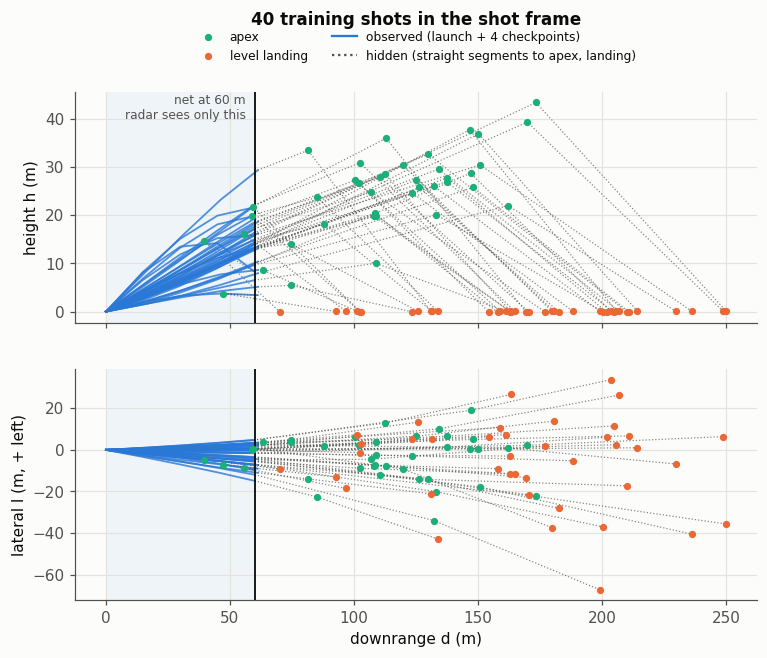

In [8]:
rng = np.random.default_rng(7)
sample = train_f.iloc[rng.choice(len(train_f), 40, replace=False)]
fig, (ax_side, ax_top) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=[1, 1])
for _, r in sample.iterrows():
    seen_d = [0] + [r[f"{cp}_d"] for cp in CHECKPOINT_NAMES]
    seen_h = [0] + [r[f"{cp}_h"] for cp in CHECKPOINT_NAMES]
    seen_l = [0] + [r[f"{cp}_l"] for cp in CHECKPOINT_NAMES]
    hid_d = [seen_d[-1], r["apex_d"], r["landing_d"]]
    ax_side.plot(seen_d, seen_h, color=BLUE, lw=1.2, alpha=0.8)
    ax_side.plot(hid_d, [seen_h[-1], r["apex_h"], r["landing_h"]], color=INK_2, lw=0.8, ls=":", alpha=0.7)
    ax_top.plot(seen_d, seen_l, color=BLUE, lw=1.2, alpha=0.8)
    ax_top.plot(hid_d, [seen_l[-1], r["apex_l"], r["landing_l"]], color=INK_2, lw=0.8, ls=":", alpha=0.7)
ax_side.scatter(sample["apex_d"], sample["apex_h"], s=14, color=AQUA, zorder=3, label="apex")
ax_side.scatter(sample["landing_d"], sample["landing_h"], s=14, color=ORANGE, zorder=3, label="level landing")
ax_top.scatter(sample["apex_d"], sample["apex_l"], s=14, color=AQUA, zorder=3)
ax_top.scatter(sample["landing_d"], sample["landing_l"], s=14, color=ORANGE, zorder=3)
for ax in (ax_side, ax_top):
    ax.axvspan(0, 60, color=BLUE, alpha=0.06, lw=0)
    ax.axvline(60, color=INK, lw=1.2)
ax_side.annotate("net at 60 m\nradar sees only this", (60, 40), xytext=(-6, 0), textcoords="offset points", ha="right", color=INK_2, fontsize=8)
ax_side.plot([], [], color=BLUE, label="observed (launch + 4 checkpoints)")
ax_side.plot([], [], color=INK_2, ls=":", label="hidden (straight segments to apex, landing)")
ax_side.set_ylabel("height h (m)")
ax_side.set_title("40 training shots in the shot frame", pad=44)
ax_side.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.08), ncol=2)
ax_top.set_ylabel("lateral l (m, + left)")
ax_top.set_xlabel("downrange d (m)")
save(fig, "fig03_shot_frame_side_top")
plt.show()

The observed portion covers the first 60 m of flights that carry 69 to 254 m. Apex lies well beyond the net for most shots, so the model must extrapolate both the rise and the fall. The dotted lines are straight segments between known points, not flight paths.

## 3. Is `landing_z` simply `launch_z`?

Level landing is defined as the point where the ball returns to launch height. If that were exactly interpolated, `landing_z - launch_z` would be zero.

In [9]:
landing_dh = train_f["landing_z"] - train_f["launch_z"]
print(landing_dh.describe().round(4))
print(landing_dh.groupby(train_f["launch_z"] > ELEVATED_TEE_MIN_Z).describe().round(4))
for col in ["apex_t", "landing_t"]:
    on_grid = np.isclose(train_f[col] * 100, np.round(train_f[col] * 100), atol=1e-6).mean()
    print(f"{col}: fraction of values on a 0.01 s grid = {on_grid:.3f}")

count    491.0000
mean       0.0045
std        0.0898
min       -0.1870
25%       -0.0660
50%        0.0043
75%        0.0807
max        0.2164
dtype: float64
          count    mean     std     min     25%     50%     75%     max
launch_z                                                               
False     354.0  0.0076  0.0883 -0.1817 -0.0614  0.0059  0.0815  0.2164
True      137.0 -0.0035  0.0931 -0.1870 -0.0819 -0.0053  0.0725  0.1851
apex_t: fraction of values on a 0.01 s grid = 1.000
landing_t: fraction of values on a 0.01 s grid = 1.000


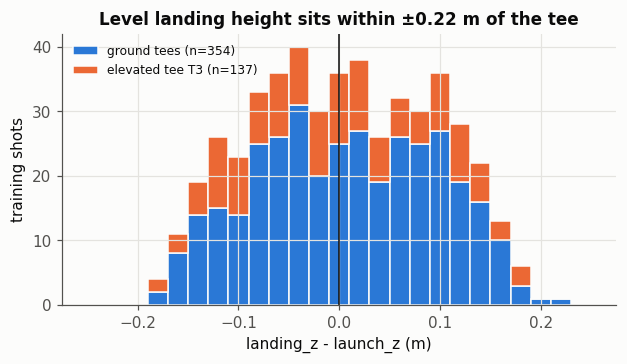

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
bins = np.linspace(-0.25, 0.25, 26)
ground = landing_dh[train_f["launch_z"] <= ELEVATED_TEE_MIN_Z]
elevated = landing_dh[train_f["launch_z"] > ELEVATED_TEE_MIN_Z]
ax.hist([ground, elevated], bins=bins, stacked=True, color=[BLUE, ORANGE], edgecolor=SURFACE, lw=1,
        label=[f"ground tees (n={len(ground)})", f"elevated tee T3 (n={len(elevated)})"])
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel("landing_z - launch_z (m)")
ax.set_ylabel("training shots")
ax.set_title("Level landing height sits within ±0.22 m of the tee")
ax.legend(fontsize=8)
save(fig, "fig04_landing_height")
plt.show()

**Finding.** `landing_z - launch_z` is centred on zero (mean about 0.005 m, sd about 0.09 m, range about ±0.2 m) for both tee heights, so `landing_z` is `launch_z` plus small noise. All `apex_t` and `landing_t` values sit on a 0.01 s grid, so these targets appear to be the nearest radar sample rather than a continuous interpolation. A ball descending at roughly 20 m/s moves about 0.2 m in 0.01 s, which matches the size of the height noise. **Consequence:** predict `landing_z = launch_z` (and later round times to 0.01 s only if it helps CV). The irreducible error on landing position from this quantisation is at the decimetre level.

## 4. Practice sessions

In [11]:
ordered = both.sort_values("launch_time")
gaps = ordered["launch_time"].diff().dropna()
print("largest gaps (s):", np.sort(gaps.to_numpy())[-14:].round(0))
for threshold in [60, 300, 1800, 3600, 6 * 3600, 20 * 3600]:
    print(f"gap threshold {threshold:>6} s -> {int((gaps > threshold).sum()) + 1} sessions")

local = pd.to_datetime(both["launch_time"], unit="s", utc=True).dt.tz_convert("Africa/Johannesburg")
sessions = both.assign(date=local.dt.date, start=local).groupby("session").agg(
    date=("date", "first"), start=("start", "min"), end=("start", "max"),
    tee=("tee", lambda s: ",".join(sorted(s.unique()))),
    train=("split", lambda s: int((s == "train").sum())), test=("split", lambda s: int((s == "test").sum())),
)
sessions["minutes"] = ((sessions["end"] - sessions["start"]).dt.total_seconds() / 60).round(0)
sessions["test_fraction"] = (sessions["test"] / (sessions["train"] + sessions["test"])).round(2)
print(sessions.drop(columns=["start", "end"]))

largest gaps (s): [2.044000e+03 2.190000e+03 2.404000e+03 2.467000e+03 7.819900e+04
 7.881000e+04 8.393800e+04 4.332300e+05 5.959890e+05 9.484620e+05
 1.213188e+06 1.461975e+06 3.446029e+06 3.715388e+06]
gap threshold     60 s -> 114 sessions
gap threshold    300 s -> 23 sessions
gap threshold   1800 s -> 16 sessions
gap threshold   3600 s -> 11 sessions
gap threshold  21600 s -> 11 sessions
gap threshold  72000 s -> 11 sessions
               date tee  train  test  minutes  test_fraction
session                                                     
0        2026-02-06  T2     12    20     21.0           0.62
1        2026-02-11  T2     45    61    111.0           0.58
2        2026-02-12  T2     61    60     83.0           0.50
3        2026-02-13  T1     26    20     26.0           0.43
4        2026-02-24  T1     21    29     36.0           0.58
5        2026-02-25  T1     88    93    138.0           0.51
6        2026-03-04  T1     72    93    167.0           0.56
7        2026-04-1

**Finding.** Within a day no gap exceeds about 41 minutes, while consecutive days are at least 21.7 hours apart, so any threshold from 1 h to 20 h gives the same **11 sessions, one per calendar day** (February to June 2026). Two further facts matter for validation:

* **Every session uses exactly one tee**, so session and tee are the same grouping.
* **Every session is split between train and test** (test fraction 0.38 to 0.62). The train/test split was random within sessions, not by session.

This means grouped-by-session CV is a *harder* test than the real test set, where every test shot has sibling shots from the same session in train. Step 3 should report both grouped and ordinary shuffled CV.

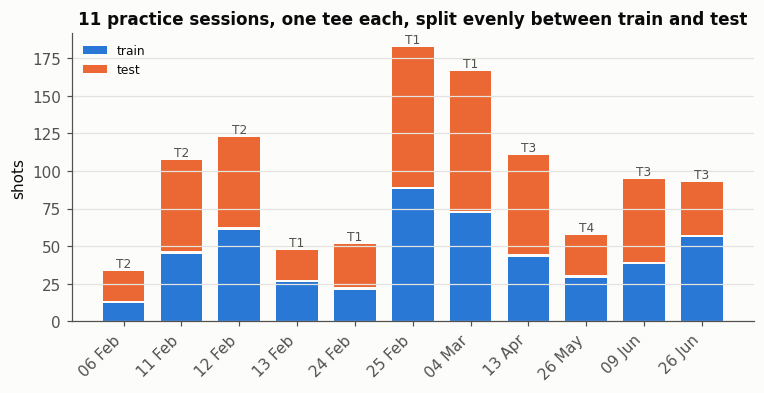

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.4))
idx = np.arange(len(sessions))
ax.bar(idx, sessions["train"], color=BLUE, width=0.72, label="train")
ax.bar(idx, sessions["test"], bottom=sessions["train"] + 1.5, color=ORANGE, width=0.72, label="test")
for i, row in enumerate(sessions.itertuples()):
    ax.annotate(row.tee, (i, row.train + row.test + 2), xytext=(0, 2), textcoords="offset points",
                ha="center", fontsize=8, color=INK_2)
ax.set_xticks(idx, [pd.Timestamp(d).strftime("%d %b") for d in sessions["date"]], rotation=45, ha="right")
ax.set_ylabel("shots")
ax.set_title("11 practice sessions, one tee each, split evenly between train and test")
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="x", visible=False)
save(fig, "fig05_sessions")
plt.show()

## 5. What drives the targets

In [13]:
def launch_summary(df):
    speed = np.sqrt(df["launch_vd"] ** 2 + df["launch_vl"] ** 2 + df["launch_vh"] ** 2)
    return pd.DataFrame({
        "ball_speed": speed,
        "launch_angle": np.degrees(np.arctan2(df["launch_vh"], np.hypot(df["launch_vd"], df["launch_vl"]))),
        "launch_direction": np.degrees(np.arctan2(df["launch_vl"], df["launch_vd"])),
    }, index=df.index)

both = both.join(launch_summary(both))
train_f = both[both["split"] == "train"].copy()
corr_cols = ["ball_speed", "launch_angle", "launch_direction", "launch_spin_rate",
             "apex_t", "apex_d", "apex_l", "apex_h", "landing_t", "landing_d", "landing_l"]
print(train_f[corr_cols].corr().round(2))
print("apex_d / landing_d:", (train_f["apex_d"] / train_f["landing_d"]).describe().round(3).to_dict())
print("apex_l / landing_l correlation:", round(train_f["apex_l"].corr(train_f["landing_l"]), 3))

                  ball_speed  launch_angle  launch_direction  \
ball_speed              1.00         -0.70              0.28   
launch_angle           -0.70          1.00             -0.20   
launch_direction        0.28         -0.20              1.00   
launch_spin_rate       -0.63          0.70             -0.10   
apex_t                  0.80         -0.29              0.27   
apex_d                  0.98         -0.64              0.30   
apex_l                 -0.01         -0.06              0.76   
apex_h                  0.51          0.16              0.17   
landing_t               0.72         -0.14              0.24   
landing_d               0.97         -0.62              0.28   
landing_l              -0.06         -0.03              0.61   

                  launch_spin_rate  apex_t  apex_d  apex_l  apex_h  landing_t  \
ball_speed                   -0.63    0.80    0.98   -0.01    0.51       0.72   
launch_angle                  0.70   -0.29   -0.64   -0.06    0.16   

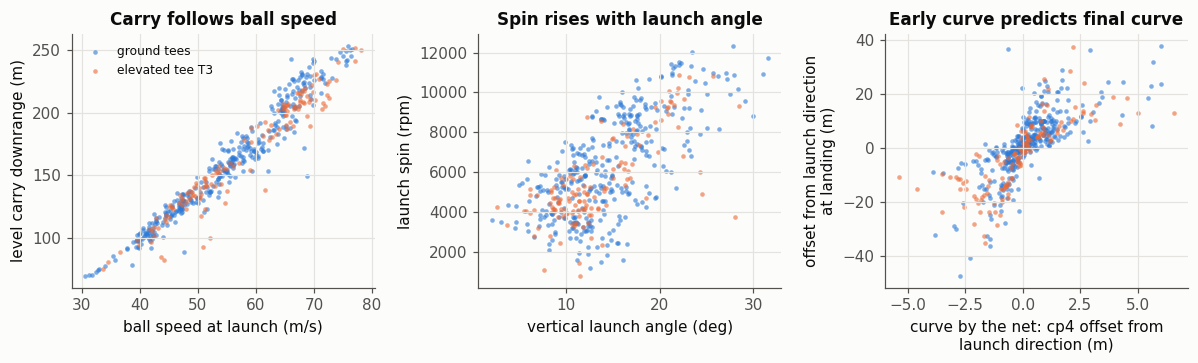

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
ground = train_f["launch_z"] <= ELEVATED_TEE_MIN_Z
for mask, color, label in [(ground, BLUE, "ground tees"), (~ground, ORANGE, "elevated tee T3")]:
    sub = train_f[mask]
    axes[0].scatter(sub["ball_speed"], sub["landing_d"], s=9, color=color, alpha=0.6, lw=0, label=label)
    axes[1].scatter(sub["launch_angle"], sub["launch_spin_rate"], s=9, color=color, alpha=0.6, lw=0)
    axes[2].scatter(sub["cp4_l"] - sub["cp4_d"] * np.tan(np.radians(sub["launch_direction"])), sub["landing_l"] - sub["landing_d"] * np.tan(np.radians(sub["launch_direction"])),
                    s=9, color=color, alpha=0.6, lw=0)
axes[0].set_xlabel("ball speed at launch (m/s)")
axes[0].set_ylabel("level carry downrange (m)")
axes[0].set_title("Carry follows ball speed")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("vertical launch angle (deg)")
axes[1].set_ylabel("launch spin (rpm)")
axes[1].set_title("Spin rises with launch angle")
axes[2].set_xlabel("curve by the net: cp4 offset from\nlaunch direction (m)")
axes[2].set_ylabel("offset from launch direction\nat landing (m)")
axes[2].set_title("Early curve predicts final curve")
fig.tight_layout()
save(fig, "fig06_target_drivers")
plt.show()

In [15]:
side = both.copy()
side["curve_at_net"] = side["cp4_l"] - side["cp4_d"] * np.tan(np.radians(side["launch_direction"]))
side["curve_at_landing"] = side["landing_l"] - side["landing_d"] * np.tan(np.radians(side["launch_direction"]))
t = side[side["split"] == "train"]
print("corr(curve at net, curve at landing):", round(t["curve_at_net"].corr(t["curve_at_landing"]), 3))
print("corr(ball speed, landing_d):", round(t["ball_speed"].corr(t["landing_d"]), 3))
print("corr(launch angle, spin):", round(t["launch_angle"].corr(t["launch_spin_rate"]), 3))

corr(curve at net, curve at landing): 0.746
corr(ball speed, landing_d): 0.97
corr(launch angle, spin): 0.697


Carry downrange is almost a linear function of ball speed, with the residual spread (tens of metres at a given speed) left to launch angle and spin. Spin rises with launch angle, as expected when the data mixes clubs from drivers to wedges. The sideways curve already visible at the net is a strong predictor of the final curve, which is the sidespin signal the physics inverse solve will exploit.

## 6. Are train and test inputs from the same distribution?

In [16]:
from scipy.stats import ks_2samp
checks = ["ball_speed", "launch_angle", "launch_direction", "cp4_t", "cp4_h", "cp4_l"]
rows = []
for col in checks:
    a = both.loc[both["split"] == "train", col]
    b = both.loc[both["split"] == "test", col]
    stat, p = ks_2samp(a, b)
    rows.append({"feature": col, "train mean": a.mean(), "test mean": b.mean(), "KS stat": stat, "p": p})
print(pd.DataFrame(rows).round(3))

both["speed_band"] = pd.cut(both["ball_speed"], [0, 40, 50, 60, 70, 80])
print(pd.crosstab(both["speed_band"], both["split"]))
print(both.groupby(["session", "split"])["ball_speed"].mean().unstack().round(1).assign(test_minus_train=lambda x: x["test"] - x["train"]))
centred = both["ball_speed"] - both.groupby("session")["ball_speed"].transform("mean")
print("KS on session-centred ball speed:", ks_2samp(centred[both["split"] == "train"], centred[both["split"] == "test"]))
print("test shots faster than the fastest training shot:", int((both.loc[both["split"] == "test", "ball_speed"] > both.loc[both["split"] == "train", "ball_speed"].max()).sum()))

            feature  train mean  test mean  KS stat      p
0        ball_speed      55.735     57.448    0.125  0.001
1      launch_angle      14.219     14.146    0.077  0.087
2  launch_direction      -2.882     -2.392    0.068  0.170
3             cp4_t       1.521      1.490    0.121  0.001
4             cp4_h      15.123     14.769    0.077  0.081
5             cp4_l      -2.930     -2.489    0.063  0.237
split       test  train
speed_band             
(0, 40]       42     30
(40, 50]     137    135
(50, 60]     138    141
(60, 70]     133    148
(70, 80]     109     37
split    test  train  test_minus_train
session                               
0        42.8   44.2              -1.4
1        59.4   56.7               2.7
2        52.4   51.1               1.3
3        55.0   55.4              -0.4
4        61.6   58.2               3.4
5        56.1   55.1               1.0
6        54.9   53.8               1.1
7        61.9   60.5               1.4
8        63.0   65.0         

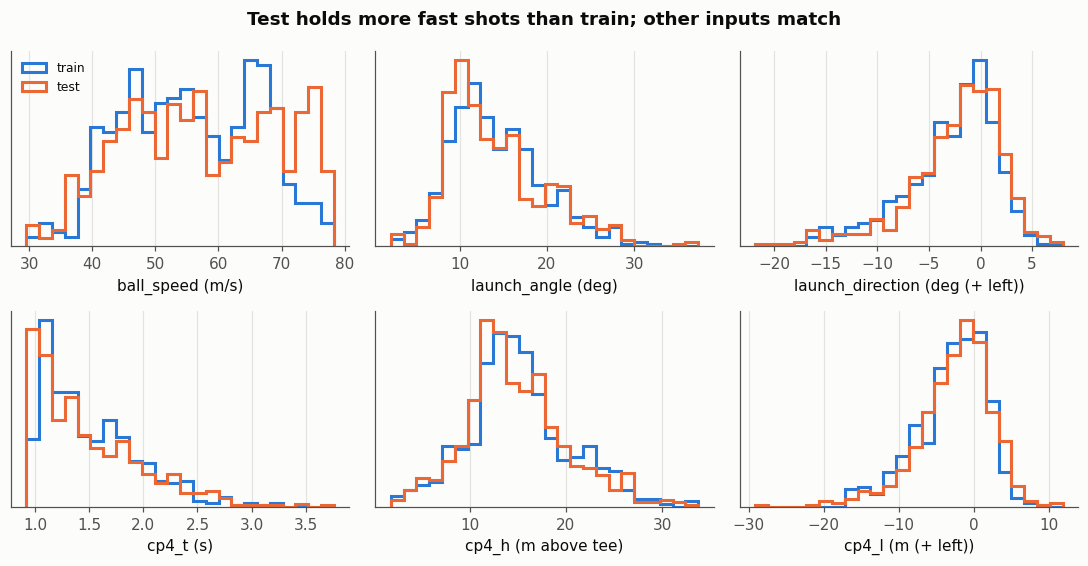

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.2))
units = {"ball_speed": "m/s", "launch_angle": "deg", "launch_direction": "deg (+ left)",
         "cp4_t": "s", "cp4_h": "m above tee", "cp4_l": "m (+ left)"}
for ax, col in zip(axes.ravel(), checks):
    a = both.loc[both["split"] == "train", col]
    b = both.loc[both["split"] == "test", col]
    bins = np.histogram_bin_edges(np.r_[a, b], bins=24)
    ax.hist(a, bins=bins, density=True, histtype="step", lw=2, color=BLUE, label="train")
    ax.hist(b, bins=bins, density=True, histtype="step", lw=2, color=ORANGE, label="test")
    ax.set_xlabel(f"{col} ({units[col]})")
    ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
fig.suptitle("Test holds more fast shots than train; other inputs match", fontweight="bold")
fig.tight_layout()
save(fig, "fig07_train_test_inputs")
plt.show()

**Finding.** Launch angle, launch direction and checkpoint height and lateral offset match between train and test (KS p > 0.05). Ball speed does not: test has about three times as many shots above 70 m/s (109 against 37), its mean ball speed is higher in 8 of 11 sessions, and the difference remains after centring each session (KS p about 0.015). The split is "mostly random" but under-samples fast, driver-like shots in train. Only 2 test shots are faster than the fastest training shot, so the range is covered, just thinly at the top end. `cp4_t` differs for the same reason, since faster shots reach the net sooner.

## Summary

* **Heading.** 28.367° anticlockwise from +x, determined to numerical precision from the checkpoint lines. Stored as `inrange.frame.HEADING_RAD`.
* **Checkpoints.** Fixed lines 15, 30, 45 and 60 m beyond a common tee line. The elevated tee T3 sits 1.26 m behind that line (`tee_d`).
* **Shot frame.** Tee-centred downrange / lateral (+ left) / height frame, round trip exact.
* **Landing height.** `landing_z = launch_z` to within ±0.22 m; landing and apex times are quantised to 0.01 s.
* **Sessions.** 11 sessions (one per day, one tee each), every one split between train and test. Grouped CV is pessimistic relative to the real test set.
* **Split shift.** Test has 109 shots above 70 m/s against 37 in train, higher mean ball speed in 8 of 11 sessions, and the shift survives removing session means. Only 2 test shots exceed the fastest training shot, so this is under-representation rather than extrapolation, but long carries are where landing errors are largest. CV should report error by speed band, and physics-based extrapolation is favoured.
* **Drivers.** Ball speed dominates carry; launch angle tracks spin; curve at the net predicts curve at landing.